In [ ]:
#In case you want to run the code:
#imports
import pandas as pd
import geopandas as gpd

#required import for geopandas (as we are using it), that was not auto installed as a dependency
import pyarrow

# Data reading
import requests
from io import BytesIO, StringIO
from shapely import wkt, distance, LineString

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
#import leafmap.foliumap as leafmap

# numpy
import numpy as np

# Feature Engineering
from sklearn.preprocessing import StandardScaler

# Unsupervised Learning
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Model requirements
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


# Model validation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc, precision_score, recall_score

Sections:
Introduction (data origin, feature descriptions, and motivating question(s))

Exploratory Data Analysis (Graphs and Summary Statistics and what you can learn from it)

Machine Learning (At least two methods relevant to the data)

Summary and Conclusions

Limitations and Recommendations for future work.

# Introduction

### Data Origin
This dataset was retrieved from the New York Open Data Program,
an open-source repository for New York State’s publicly available datasets.
It contains 2024 Metropolitan Transportation Authority (MTA) ridership data
estimated and collected from MetroCard swipe and contactless MTA payment
systems (OMNY). The original dataset represents aggregated ridership from
each origin-destination combination along with the month, hour, and day of
the week.

### Feature Descriptions
**Variables:**
- Timestamp (Year, Month, Hour, Day of Week)  |  *Datetime*
- Origin / Destination Station ID + Name  |  *Number/Text*
- Station Latitude / Longitude Coordinates  |  *Number*
- Estimated Average Ridership  |  *Number*
- Origin Point (Geospatial)  |  *Point Feature*

### Motivating Questions
Within this dataset, we are most interested in the sum_estimated_average_ridership column.
This column represents the average estimated number of passengers aggregated by origin station,
month, hour, and day of the week. To begin, we want to examine patterns within the ridership variable
related to month, time or day, day of the week, and origin structure. For example, do subway stations
cluster into distinct communities? Do seasons contribute to average ridership? Which stations have the
largest demand?

Overall, however, our main question is *can we accurately forcast station ridership?*


# Exploratory Data Analysis

### Cleaning the Data
For this project, we had two datasets: origin_data (aggregated average estimated ridership
by station, month, day of the week, and hour) and origin_destination (included sum average estimated ridership and distance for each pair of origin and destination stations)

#### origin_data
The data cleaning of origin_data was fairly straight forward; all that needed to be done was
to organize the rows, standardize the column names-to remove spaces and capitalization-and
transform the ridership column into numeric data (removing the comma) for easier and better analysis.

In [ ]:
#Reading in the data
url = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/refs/heads/main/Data/Raw/origin_ridership_time_series.csv"
origin_raw = pd.read_csv(StringIO(requests.get(url, verify=False).text))

# Organize rows by station, month, day of week, and hour of day
origin = (
    origin_raw
    .sort_values(by=["Origin Station Complex ID", "Month", "Day of Week", "Hour of Day"])
)

# Standardize column names
origin.columns = origin.columns.str.strip().str.lower().str.replace(" ", "_")

# Turn the ridership column to numeric (remove commas)
origin['sum_estimated_average_ridership'] = (
    pd.to_numeric(origin_raw['sum_estimated_average_ridership'].str.replace(',', ''))
)

#### origin_destination
For origin_destination, we also had to standardize column names and transform the ridership column to numeric data. Similarly, however, we turned the 'origin_point' and 'destination_point' variables into geometry objects and added them to a GeoDataFrame so that they can be effectively graphed. In this GeoDataFrame, we also added the log(ridership), the distance between each station, and a new ridership per kilometer variable.

In [ ]:
#Reading in the data
url = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/refs/heads/main/Data/Raw/origin_destination_flows.csv"
od_flows_raw = pd.read_csv(StringIO(requests.get(url, verify=False).text))
od_flows = od_flows_raw.copy()

# Standardize column names
od_flows.columns = od_flows_raw.columns.str.strip().str.lower().str.replace(" ", "_")

# Turn the ridership column to numeric (remove commas)
od_flows['sum_estimated_average_ridership'] = (
    pd.to_numeric(od_flows_raw['sum_estimated_average_ridership'].str.replace(',', ''))
)

#Turn the Point Data into a Geometry Type
od_flows["origin_point"] = od_flows["origin_point"].apply(wkt.loads)
od_flows["destination_point"] = od_flows["destination_point"].apply(wkt.loads)

#Turn into a GroDataFrame for mapping
od_flows["geometry"] = od_flows.apply(
    lambda row: LineString([
        row["origin_point"],
        row["destination_point"]
    ]),
    axis=1
)

od_flows_geo = gpd.GeoDataFrame(
    od_flows,
    geometry="geometry",
    crs="EPSG:4326"
)

#Calculate distance between two stations
od_projected = od_flows_geo.to_crs("EPSG:32618")

od_flows_geo["distance_meters"] = od_projected.length
od_flows_geo["distance_km"] = od_flows_geo["distance_meters"] / 1000

#Log of ridership (skewed)
od_flows_geo["log_ridership"] = np.log1p(od_flows_geo["sum_estimated_average_ridership"])

#Riders per kilometer
od_flows_geo["riders_per_km"] = (
    od_flows_geo["sum_estimated_average_ridership"] /
    od_flows_geo["distance_km"]
)

od_flows_geo["geometry"] = od_flows_geo.apply(
    lambda row: LineString([row["origin_point"], row["destination_point"]]), axis=1
)

od_flows_geo["origin_point_wkt"] = od_flows_geo["origin_point"].apply(lambda g: g.wkt)
od_flows_geo["destination_point_wkt"] = od_flows_geo["destination_point"].apply(lambda g: g.wkt)

od_flows_geo.drop(columns=["origin_point", "destination_point"]) \
    .set_geometry("geometry") \
    .to_parquet("origin_destination_flows_CLEAN.parquet")

### Summary Statistics

#### Table 1

In [ ]:
#Creating the Table 1
#Finding proportions for categorical variables and means for numeric variables
# sort by month
origin_sorted = origin.sort_values(by='month')

# Group by month and count occurrences
month_counts = origin_sorted['month'].value_counts()

# Step 3: Calculate percentages
total_month_count = month_counts.sum()
month_percentages = (month_counts / total_month_count) * 100

# proportions for day of the week

week_counts = origin['day_of_week'].value_counts()

# Calculate percentages
total_week_count = week_counts.sum()
week_percentages = (week_counts / total_week_count) * 100

# hour of day proportions

hour_counts = origin['hour_of_day'].value_counts()
hour_counts_df = hour_counts.reset_index().sort_values(by = 'hour_of_day')

# Calculate percentages
total_hour_count = hour_counts.sum()
hour_percentages = (hour_counts / total_hour_count) * 100
hour_percent_df = hour_percentages.reset_index().sort_values(by = 'hour_of_day')

# station proportions

station_counts = origin['origin_station_complex_name'].value_counts()

# Calculate percentages
total_station_count = station_counts.sum()
station_percentages = (station_counts / total_station_count) * 100

# counts just for most pop 5 and least pop 5
origin_st = station_counts.reset_index()
means = origin.groupby('origin_station_complex_name')['sum_estimated_average_ridership'].agg(['sum','mean','std'])

# Merge the DataFrames on the station column
descriptive_st = pd.merge(origin_st, means, on='origin_station_complex_name', how='inner')
# sort by ridership count to get mean/std for most popular and least popular
least5_st = descriptive_st.sort_values(by = 'sum').head()
most5_st = descriptive_st.sort_values(by = 'sum', ascending=False).head()

# proportions just for most pop 5 and least pop 5
origin_stations = station_percentages.reset_index()
origin_stations.rename(columns = {'count': 'proportion'}, inplace = True)
means = origin.groupby('origin_station_complex_name')['sum_estimated_average_ridership'].agg(['sum','mean','std'])

# Merge the DataFrames on the station column
descriptive_station = pd.merge(origin_stations, means, on='origin_station_complex_name', how='inner')
# sort by ridership count to get mean/std for most popular and least popular
least5_stations = descriptive_station.sort_values(by = 'sum').head()
most5_stations = descriptive_station.sort_values(by = 'sum', ascending=False).head()

# Means and standard deviations for numeric columns
# will ignore the columns we know are actually categorical (month, hour, id)

# origin_point proportions
origin_counts = origin['origin_point'].value_counts()

# Step 3: Calculate percentages
total_origin_count = origin_counts.sum()
origin_percentages = (origin_counts / total_origin_count) * 100

# 5 least popular stations
# sort by ridership
least_pop_stations = origin.groupby('origin_station_complex_name')['sum_estimated_average_ridership'].sum().sort_values().head()

origin.groupby('origin_station_complex_name')['sum_estimated_average_ridership'].agg(['sum','mean','std']).sort_values(by = 'sum').head()

# 5 most popular stations
origin.groupby('origin_station_complex_name')['sum_estimated_average_ridership'].agg(['sum','mean','std']).sort_values(by = 'sum', ascending=False).head()

# mean and std of sum avg ridership by hour
origin.groupby('hour_of_day')['sum_estimated_average_ridership'].agg(['mean','std']).sort_values(by = 'hour_of_day')

# order days of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
origin['day_of_week'] = pd.Categorical(origin['day_of_week'], categories=day_order, ordered=True)

# mean and std of sum avg ridership by day
origin.groupby('day_of_week')['sum_estimated_average_ridership'].agg(['mean','std']).sort_values(by = 'day_of_week')

# mean and std of sum avg ridership by month
origin.groupby('month')['sum_estimated_average_ridership'].agg(['mean','std']).sort_values(by = 'month')

![first part of table 1](images/table1_one.png)
![second part of table 1](images/table1_two.png)
![third part of table 1](images/table1_three.png)

Table 1 contains columns:
"Factor Related to Ridership": listing variables we explored in being able to predict ridership.
"No.": providing the counts of each variable as it appears in that column.
"%": providing the percentage each variable makes up of the total number of items within that column.
"Ridership Mean": providing the sum estimated ridership mean for that particular variable.
"Ridership st. dev.": providing the sum estimated ridership standard deviation for that particular variable.

The Factors Related to Ridership included are month, day of week, hour of day, and origin station. Orgin Station includes a large number of variables, so we look at the five most popular station, determined by the greatest sum estimated average ridership, and the five least popular stations, determined by the least sum estimated average ridership.

Viewing the composition of each of these variables gives us insight into how the data is composed. For each factor, each variable is roughly equally represented in the data. For example each individual month makes up for about 8.3% of the data. In constrast, means and st devs of summed ridership for each variable within each factor are not necessarily similar. This indicates that ridership could be predicted by these factors.

### Data Visualizations
Firstly, we wanted to visualize the data in order to see if there were any patterns in ridership
for day of the week, hour of the day, month of the year, and season

In [ ]:
# origin day of week
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
total_ridership_per_day_of_week = [origin[origin['day_of_week'] == i]['sum_estimated_average_ridership'].sum() for i in day_of_week]
plt.bar(day_of_week, total_ridership_per_day_of_week)
plt.tick_params(axis='x', labelrotation=45)
# plt.ticklabel_format(style='plain') #for some reason this is only causing an error for this graph
plt.show()
print('Day of the week: total ridership')
for i in range(7):
    print(f'{day_of_week[i]}: {total_ridership_per_day_of_week[i]}')

Unsurprisingly, it appears that there is a higher average estimated ridership on weekdays than
there is on weekends. This is most likely because one of the subway's primary purposes is for
commuters, who would not be utilizing it on weekends. There is also a slight increase in
ridership on Tuesday, Wednesday, and Thursday. As this is 2024 data, many workers have now started
to split their time between in-person and remote work. We hypothesize that this increase may be
due to more workers choosing to go in-person on Tuesday, Wednesday, or Thursday rather than
Monday or Friday

In [ ]:
# origin hour of day
hour_of_day = origin['hour_of_day'].unique()
total_ridership_per_hour_of_day = [origin[origin['hour_of_day'] == i]['sum_estimated_average_ridership'].sum() for i in hour_of_day]
plt.bar(hour_of_day, total_ridership_per_hour_of_day)
plt.tick_params(axis='x', labelrotation=45)
plt.ticklabel_format(style='plain')
plt.show()
print('hour of the day: total ridership')
for i in range(len(hour_of_day)):
    print(f'{hour_of_day[i]}: {total_ridership_per_hour_of_day[i]}')

This graph shows a commuting trend as well. Ridership appears to peak at approximately 8 am and
5 pm. This falls in line with the average workday being from 9-5 with workers having to leave
before 9 in order to get to their workplace in time.

In [ ]:
# origin month of year
month = origin['month'].unique()
total_ridership_per_month = [origin[origin['month'] == i]['sum_estimated_average_ridership'].sum() for i in month]
plt.bar(month, total_ridership_per_month)
plt.tick_params(axis='x', labelrotation=45)
plt.ticklabel_format(style='plain')
plt.show()
print('month of the year: total ridership')
for i in range(len(month)):
    print(f'{month[i]}: {total_ridership_per_month[i]}')

Average estimated ridership appears to decrease at two time periods: November-February and July-August. These two time periods also correspond with the holiday season as well as summer,
which is notably when most people tend to take time off of work. While the winter decrease in
ridership goes longer than we expected, both of these decreases are logical.

In [ ]:
# Create a column 'Season' based on Month
origin['season'] = np.select(
    [
        (origin['month'] >= 3) & (origin['month'] <= 5),          # Condition 1
        (origin['month'] >= 6) & (origin['month'] <= 8),  # Condition 2
        (origin['month'] >= 9) & (origin['month'] <= 11),
        (origin['month'] == 12) | (origin['month'] <= 2)
    ],
    [
        'spring',  # Value if Condition 1 is True
        'summer',    # Value if Condition 2 is True
        'fall',
        'winter'
    ],
    default='Unknown'
)

season = ['winter', 'spring', 'summer', 'fall']

#Graphing
season = origin['season'].unique()
total_ridership_per_season = [origin[origin['season'] == i]['sum_estimated_average_ridership'].sum() for i in season]
plt.bar(season, total_ridership_per_season)
plt.tick_params(axis='x', labelrotation=45)
plt.show()
print('season of the year: total ridership')
for i in range(len(season)):
    print(f'{season[i]}: {total_ridership_per_season[i]}')

This graph emphasizes the findings of the previous visualization; the winter and summer seasons had lower ridership than the fall and spring seasons. We also used the aggregated ridership data in order to create a 2D representation of the stations:

In [ ]:
#Recoding variables
hour_pivot  = origin.groupby(['origin_station_complex_name', 'hour_of_day'])['sum_estimated_average_ridership'].mean().unstack()
dow_pivot   = origin.groupby(['origin_station_complex_name', 'day_of_week'])['sum_estimated_average_ridership'].mean().unstack()
month_pivot = origin.groupby(['origin_station_complex_name', 'month'])['sum_estimated_average_ridership'].mean().unstack()

station_df  = pd.concat([hour_pivot, dow_pivot, month_pivot], axis=1)
station_df.columns = (
    [f"hour_{h:02d}" for h in range(24)] +
    [f"dow_{d}"      for d in range(7)]  +
    [f"month_{m:02d}" for m in range(1, 13)]
)

#Scale the data
X = np.array(
    station_df.reset_index()
    .drop(columns="origin_station_complex_name")
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define PCA object
pca = PCA(n_components = 2)
# Fit to the previously scaled X feature array
X_pca = pca.fit_transform(X_scaled)

# Create dataframe with first two principal components (for plotting)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Concatenate the station labels to each observation
pca_df["station"] = station_df.reset_index()["origin_station_complex_name"]

# Sort by PC1 descending to find extreme outlier stations
pca_df.sort_values(by="PC1", ascending=False).head(10)

# Scatterplot of PC1 and PC2 (Not really any patterns)
pca_df.plot(x='PC1', y = "PC2", kind='scatter')

Although there are some outliers, there do not appear to be any identifiable clusters

If you would like to see more visualizations, check out our exploratory_analysis.ipynb in our Analysis folder. We have far more graphs in that notebook than we have put into this report.

# Machine Learning

In order to estimate ridership, we used three main methods: Linear Regression with Lasso regression, Decision Tree, and XGBoost

### Linear Regression with Lasso

In [ ]:
#split into X and Y datasets
num_cols = origin.shape[1]
X = origin.iloc[:,0:num_cols-2]
X = X.drop('origin_station_complex_id', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis
X = pd.get_dummies(X, drop_first=True) #one_hot encoding here
Y = origin.iloc[:,num_cols-1:num_cols]
Y = np.ravel(Y)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

#split into X and Y datasets
num_cols = origin.shape[1]
X = origin.iloc[:,0:num_cols-2]
X = X.drop('origin_station_complex_id', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis
#one hot encoding
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, drop = 'first')
one_hot_encoded = encoder.fit_transform(X[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_encoded = pd.concat([X, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)
X = df_encoded

Y = origin.iloc[:,num_cols-1:num_cols]
Y = np.ravel(Y)


display(X)

In [ ]:
#train test split happening
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=4)

#### Using LASSO to create a model

In [ ]:
# standardize
from sklearn.preprocessing import StandardScaler

scalerX = StandardScaler().fit(X_train)
X_train_scaled = scalerX.transform(X_train)
X_test_scaled = scalerX.transform(X_test)



In [ ]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression


# Starting the lasso regression engine
lasso_10 = Lasso(alpha = 10)
lasso_10.fit(X_train, y_train)
lasso_coefs10 = lasso_10.coef_

linear_model = LinearRegression().fit(X_train, y_train)
linear_coefs = linear_model.coef_

# Viewing OLS and Lasso coefficients and how they differ
pd.DataFrame({
    'term' : X_train.columns,
    'OLS'  : linear_coefs,
    'Lasso': lasso_coefs10,
    'estimate_diff': (lasso_coefs10 - linear_coefs)#.round().astype(int)
})#.query('estimate_diff != 0')

In [ ]:
# how many coeffs aren't zero
sum(np.abs(lasso_10.coef_) > 0)

In [ ]:
# Getting the coefficients of the model for the best choice of lambda
vars_matter_df = pd.DataFrame({
    'feature' : X.columns,
    'estimate': lasso_10.coef_.round(2)
}).query('estimate != 0')
display(vars_matter_df)



Using lambda = 10 in our lasso regression, we find month, hour of day, Saturday, Sunday, and Times Square station to be our
significant predictors for ridership.

In [ ]:
# fit mlr model with significant predictors

best_mlr = (
    LinearRegression()
    .fit(
        X = X_train[vars_matter['feature']],
        y = y_train
    )
)

display(pd.DataFrame({
    'feature' : vars_matter['feature'],
    'estimate': best_mlr.coef_.round(2)
}))

# Creating an R-squared plot:
sns.lmplot(
    data = pd.DataFrame({
        'y': y_test,
        'y_hat': best_mlr.predict(X = X_test[vars_matter['feature']])
    }),
    x = 'y_hat',
    y = 'y',
    line_kws = {'color': 'red'},
    scatter_kws = {'s' : 10}
)

plt.show()

In [ ]:
origin[origin['origin_station_complex_name'] != 'Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)']['sum_estimated_average_ridership'].mean()

In [ ]:
origin[origin['origin_station_complex_name'] == 'Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)']['sum_estimated_average_ridership'].mean()

Above we looked at the mean estimated average ridership excluding Times Square Station and exclusively and found vastly different numbers. The mean sum of estimated average ridership for Times Square Station was 5187.42, while it was only 310.77 across all other stations. Considering the distribution of the points in the graph above, Times Square ridership may provide an explanation to the clumps of points separate from the main clump of points that exist at the higher predicted values. Since it is one of our predictors, the model may only predict high ridership if Times Square is the given station.

In [ ]:
# finding r^2
best_mlr.score(X_test[vars_matter['feature']], y_test)

The R-squared value for our MLR model using the predictors chosen from Lasso(lamda = 10) is 0.4915. This is a moderately weak score, indicating these variables, at least on their own, might not be predicting ridership all that well. Looking at the plot, the model seems to have a difficult time predicting high sum estimated averages of ridership.

#### LASSO using CV to choose lambda

In [ ]:
# 5-fold cross-validation to choose lambda
from sklearn.linear_model import LassoCV

lasso_cv_model = LassoCV(
   alphas=np.arange(0.01, 10, 0.2), cv=5, max_iter=100000
)

# fit model on train set
lasso_best = lasso_cv_model.fit(X_train_scaled, y_train)

In [ ]:
# chosen value of lambda
lasso_best.alpha_

In [ ]:
# Getting the coefficients of the model for the best choice of lambda
vars_matter_df_2 = pd.DataFrame({
    'feature' : X.columns,
    'estimate': lasso_best.coef_.round(2)
}).query('estimate != 0')
display(vars_matter_df_2)

Using cross validation we find the best value of lamda for LASSO regression to be 0.01. After using this value to fit a LASSO model, we find that 430 out of 433 of our possible predictors are significant. In this sense, running LASSO is suggesting that we will make our best predictions of ridership using basically all of our predictors.

In [ ]:
# fit mlr model with significant predictors


best_mlr_2 = (
    LinearRegression()
    .fit(
        X = X_train[vars_matter_df_2['feature']],
        y = y_train
    )
)

display(pd.DataFrame({
    'feature' : vars_matter_df_2['feature'],
    'estimate': best_mlr_2.coef_.round(2)
}))

# Creating an R-squared plot:
sns.lmplot(
    data = pd.DataFrame({
        'y': y_test,
        'y_hat': best_mlr_2.predict(X = X_test[vars_matter_df_2['feature']])
    }),
    x = 'y_hat',
    y = 'y',
    line_kws = {'color': 'red'},
    scatter_kws = {'s' : 10}
)

plt.show()

In [ ]:
best_mlr_2.score(X_test[vars_matter_df_2['feature']], y_test)

After fitting a MLR model with our 430 significant predictors, we find that the r-squared value is 0.5084. This indicated a moderately weak strength for our model. This r-squared value is a slight improvement from our previous model with the 5 predictors, but not by much. In this sense, we may look towards other implications than r-squared as to which model to use. Using cross-validation to find the best value of lamda did improve our r-squared value, and thus give us a "better" model, however we have a much more complex model than we did when we chose predictors from a LASSO model using lamda=10. The point of LASSO is to decrease our risk for overfitting the data. By choosing to run the MLR model based on the cv value for lambda, we have not changed our risk of overfitting by much as our model is still very complex. For this reason, it may be worth using a different value of lambda, like how we have tested 10, to determine a smaller number of significant predictors leading to a simpler model that is less complex, has less variability, and less prone to the issue of overfitting.

### Decision Tree Model

In [ ]:
#full model takes a while

In [13]:
ridership_tree = (
    DecisionTreeRegressor(random_state = 3870)
    .fit(X = X_train, y = y_train)
)

In [9]:
R2_train = ridership_tree.score(X_train, y_train)
R2_test = ridership_tree.score(X_test, y_test)

print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')

R-squared for the training set is: 1.00 and the R-squared of the test set is  0.99


#### Pruning the tree

In [17]:
from sklearn.model_selection import GridSearchCV


param_grid = {'max_depth':range(1, 200, 3)}
cross_val_tree = DecisionTreeRegressor()
search = GridSearchCV(cross_val_tree, param_grid, cv=5, scoring = 'r2')
grid_search = search.fit(X_train, y_train)


Text(0, 0.5, 'Val Accuracy')

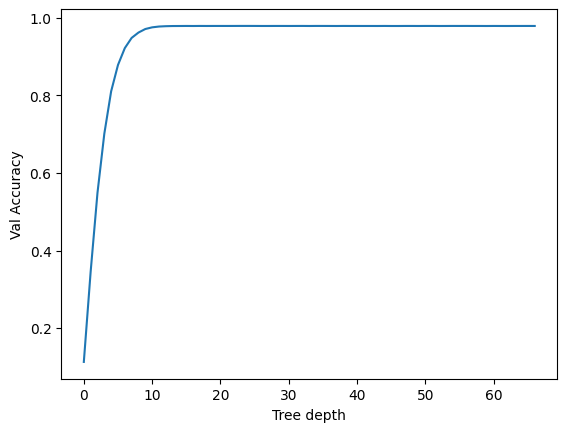

In [18]:
plt.plot(search.cv_results_['mean_test_score'])
plt.xlabel('Tree depth')
plt.ylabel('Val Accuracy')

In [24]:
depth = grid_search.best_params_['max_depth']
print(depth)
ridership_tree_pruned = DecisionTreeRegressor(max_depth=depth).fit(X_train, y_train)
R2_train = ridership_tree_pruned.score(X_train, y_train)
R2_test = ridership_tree_pruned.score(X_test, y_test)

print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')

73
R-squared for the training set is: 1.00 and the R-squared of the test set is  0.99


In [23]:
depth = 30
print(depth)
ridership_tree_pruned = DecisionTreeRegressor(max_depth=depth).fit(X_train, y_train)
R2_train = ridership_tree_pruned.score(X_train, y_train)
R2_test = ridership_tree_pruned.score(X_test, y_test)

print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')

30
R-squared for the training set is: 1.00 and the R-squared of the test set is  0.99


What we learned from this
- best depth evens out at around a depth of around 30, with the best depth being 73
- there is very little difference from a depth of 30 to 73, implying just minor improvements for a few select days
- interestingly, there is a very high r-squared on the training set, enough that we would assume potential overfitting from the data, but there is also a very high r-squared on the test set

#### Feature importance


In [19]:
feat_import_pruned = ridership_tree_pruned.feature_importances_
feat_import_full = ridership_tree.feature_importances_

feat_import_df = pd.DataFrame({
        'feature': X_train.columns,
        'full': feat_import_full,
        'pruned': feat_import_pruned
    }).sort_values(by = 'pruned').reset_index().drop(columns = 'index', axis = 1)

In [20]:
feat_import_df

,feature,full,pruned
0,origin_station_complex_name_Beach 36 St (A),9.959052e-09,7.478797e-09
1,origin_station_complex_name_Beach 44 St (A),8.482758e-09,1.024803e-08
2,origin_station_complex_name_Avenue P (F),4.191795e-08,3.916066e-08
3,origin_station_complex_name_Aqueduct Racetrack...,1.572109e-08,4.659226e-08
4,origin_station_complex_name_Avenue U (N),1.746235e-07,4.675358e-08
...,...,...,...
428,origin_station_complex_name_Grand Central-42 S...,6.423496e-02,6.423498e-02
429,origin_longitude,8.279595e-02,8.300154e-02
430,origin_latitude,1.175492e-01,9.714934e-02
431,"origin_station_complex_name_Times Sq-42 St (N,...",1.127163e-01,1.127163e-01


In [21]:
feat_import_df = feat_import_df[feat_import_df['full'] >= .01]
feat_import_df = feat_import_df[feat_import_df['pruned'] >= .01]
feat_import_df

,feature,full,pruned
418,origin_station_complex_name_34 St-Penn Station...,0.010007,0.010007
419,origin_station_complex_name_59 St-Columbus Cir...,0.010748,0.010748
420,origin_station_complex_name_Flushing-Main St (7),0.013404,0.013404
421,origin_station_complex_name_74-Broadway (7)/Ja...,0.013571,0.013571
422,month,0.015041,0.015038
424,"origin_station_complex_name_Fulton St (A,C,J,Z...",0.020661,0.020661
425,origin_station_complex_name_34 St-Herald Sq (B...,0.021675,0.021675
426,day_of_week_Saturday,0.033909,0.033909
427,day_of_week_Sunday,0.036195,0.036195
428,origin_station_complex_name_Grand Central-42 S...,0.064235,0.064235


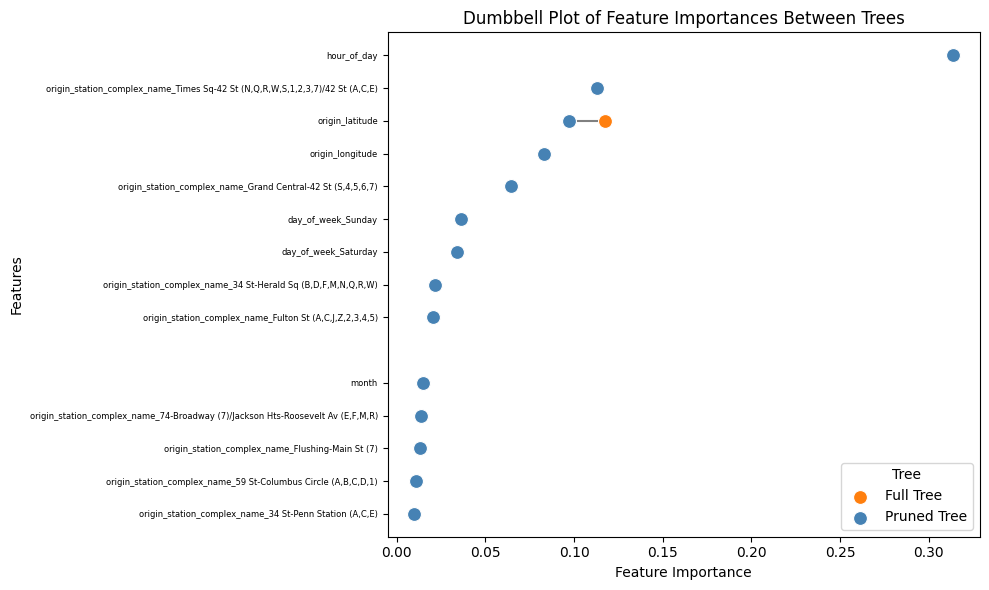

In [22]:
# Point for the full tree
# sns.set_theme(font_scale=1.5)  # Increases all text by 50%
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x = feat_import_df['full'],
    y = feat_import_df.index,
    color = '#FF7F0E',
    s = 100,
    label = 'Full Tree',
    zorder = 2
)

# Points for the pruned tree
sns.scatterplot(
    x = feat_import_df['pruned'],
    y = feat_import_df.index,
    color = 'steelblue',
    s = 100,
    label = 'Pruned Tree',
    zorder = 2
)

# Adding the lines
for i, row in feat_import_df.iterrows():
    plt.plot(
        [row['full'], row['pruned']],
        [i,i],
        color = 'grey',
        zorder = 1
    )

plt.title("Dumbbell Plot of Feature Importances Between Trees")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.yticks(feat_import_df.index, feat_import_df['feature'], fontsize = 6)
plt.legend(title='Tree', loc='lower right')
plt.tight_layout()

#### Decision Tree Without Stations

The impetus for this is that the tree appears to be quite overfit. This could be because of the vast number of stations, where the stations allow for a lot of mini-trees within the larger tree that can super easily target each ridership value. To see if this is needed, we will just be removing the stations from the dataset

In [24]:
from sklearn.preprocessing import OneHotEncoder

url_ts = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_ridership_time_series_CLEAN.csv"
origin = pd.read_csv(StringIO(requests.get(url_ts, verify=False).text))
#split into X and Y datasets
num_cols = origin.shape[1]
X = origin.iloc[:,0:num_cols-2]
X = X.drop('origin_station_complex_id', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis
X = X.drop('origin_station_complex_name', axis=1) #drop complex_id b/c it is the same as complex_name in terms of analysis

Y = origin.iloc[:,num_cols-1:num_cols]
Y = np.ravel(Y)

#one hot encoding
categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, drop = 'first')
one_hot_encoded = encoder.fit_transform(X[categorical_columns])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))
df_encoded = pd.concat([X, one_hot_df], axis=1)
df_encoded = df_encoded.drop(categorical_columns, axis=1)
X = df_encoded

# print(X)

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=4)

In [25]:
small_ridership_tree = (
    DecisionTreeRegressor(random_state = 3870)
    .fit(X = X_train, y = y_train)
)
R2_train = small_ridership_tree.score(X_train, y_train)
R2_test = small_ridership_tree.score(X_test, y_test)

# print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')
print(f'R-squared for the training set is: {np.sqrt(R2_train)} and the R-squared of the test set is {np.sqrt(R2_test)}')

R-squared for the training set is: 1.0 and the R-squared of the test set is 0.9911408130727509


In [26]:
from sklearn.model_selection import GridSearchCV

#aiming for a smaller tree
param_grid = {'max_depth':range(1, 30, 1)}
cross_val_tree = DecisionTreeRegressor()
search = GridSearchCV(cross_val_tree, param_grid, cv=5, scoring = 'r2')
grid_search = search.fit(X_train, y_train)

Text(0, 0.5, 'Val Accuracy')

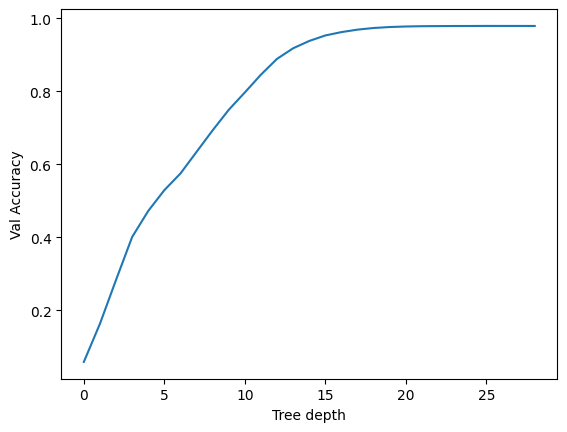

In [27]:
plt.plot(search.cv_results_['mean_test_score'])
plt.xlabel('Tree depth')
plt.ylabel('Val Accuracy')

In [28]:
depth = grid_search.best_params_['max_depth']
print(depth)
small_ridership_tree_pruned = DecisionTreeRegressor(max_depth=depth).fit(X_train, y_train)
R2_train = small_ridership_tree_pruned.score(X_train, y_train)
R2_test = small_ridership_tree_pruned.score(X_test, y_test)

# print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')
print(f'R-squared for the training set is: {np.sqrt(R2_train)} and the R-squared of the test set is {np.sqrt(R2_test)}')

26
R-squared for the training set is: 0.999751522821056 and the R-squared of the test set is 0.9910493438431711


Things we learned
- removing station names from the dataset did very little for the accuracy. this could be because longitude and latitude together make unique combinations for each station
- another problem I noticed now is 2^29 = 536870912, which means for our training dataset that there is effectivly a seperate leaf node for every row
- this is why I am trying a depth of 17 as well, because 2^17 = 131072, for an end bucket of around 5 rows in each leaf node instead of just 1

In [29]:
depth = 17
print(depth)
small_ridership_tree_17 = DecisionTreeRegressor(max_depth=depth).fit(X_train, y_train)
R2_train = small_ridership_tree_17.score(X_train, y_train)
R2_test = small_ridership_tree_17.score(X_test, y_test)

# print(f'R-squared for the training set is:{np.sqrt(R2_train): .2f} and the R-squared of the test set is {np.sqrt(R2_test): .2f}')
print(f'R-squared for the training set is: {np.sqrt(R2_train)} and the R-squared of the test set is {np.sqrt(R2_test)}')

17
R-squared for the training set is: 0.9858775904871857 and the R-squared of the test set is 0.9816809577170835


In [33]:
# import pickle

# with open('small_pruned_tree.pkl', 'wb') as f:
#     pickle.dump(small_ridership_tree_pruned, f)

In [34]:
feat_import_pruned = small_ridership_tree_pruned.feature_importances_
feat_import_full = small_ridership_tree.feature_importances_
feat_import_17 = small_ridership_tree_17.feature_importances_

feat_import_df = pd.DataFrame({
        'feature': X_train.columns,
        'full': feat_import_full,
        'pruned': feat_import_pruned,
        'depth17': feat_import_17
    }).sort_values(by = 'pruned').reset_index().drop(columns = 'index', axis = 1)

In [38]:
feat_import_df = feat_import_df[feat_import_df['full'] >= .01]
feat_import_df = feat_import_df[feat_import_df['pruned'] >= .01]
feat_import_df = feat_import_df[feat_import_df['depth17'] >= .01]

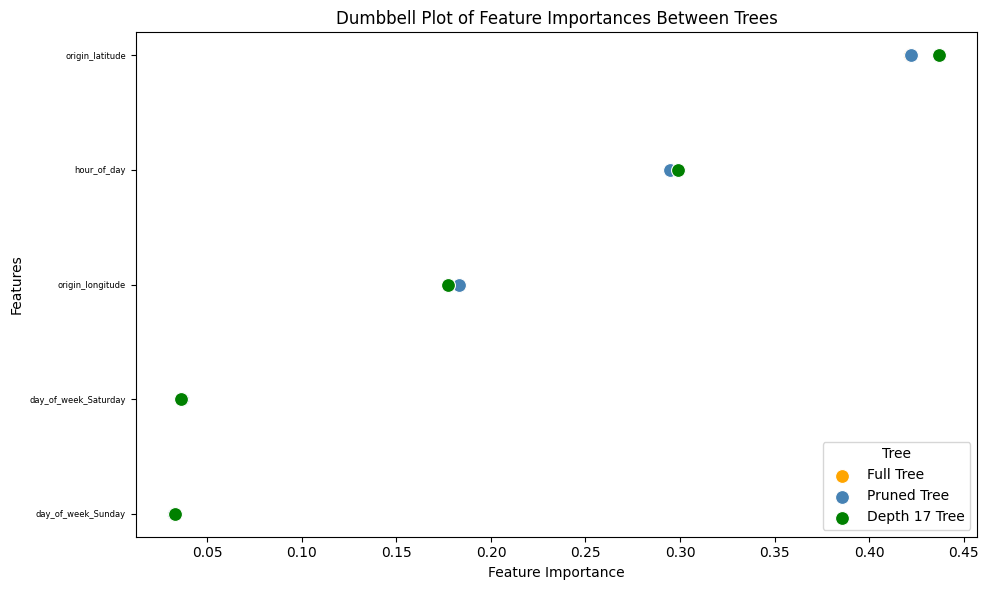

In [39]:
# Point for the full tree
# sns.set_theme(font_scale=1.5)  # Increases all text by 50%
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x = feat_import_df['full'],
    y = feat_import_df.index,
    color = 'orange',
    s = 100,
    label = 'Full Tree',
    zorder = 2
)

# Points for the pruned tree
sns.scatterplot(
    x = feat_import_df['pruned'],
    y = feat_import_df.index,
    color = 'steelblue',
    s = 100,
    label = 'Pruned Tree',
    zorder = 2
)

# Points for the depth of 17 tree
sns.scatterplot(
    x = feat_import_df['depth17'],
    y = feat_import_df.index,
    color = 'green',
    s = 100,
    label = 'Depth 17 Tree',
    zorder = 2
)

# Adding the lines
for i, row in feat_import_df.iterrows():
    plt.plot(
        [row['full'], row['pruned']],
        [i,i],
        color = 'grey',
        zorder = 1
    )

plt.title("Dumbbell Plot of Feature Importances Between Trees")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.yticks(feat_import_df.index, feat_import_df['feature'], fontsize = 6)
plt.legend(title='Tree', loc='lower right')
plt.tight_layout()

#### Interperation

We would go with the smaller tree without station names. It appears a lot of the station differences are covered by longitude and latitude, and other than that they are similar in terms of performance. For within the smaller trees, we would go with the tree with depth 17. This is because even though it does worse, it is less likely to be had too high of a variance and still predicts quite well. That being said, both the pruned and depth 17 tree perform well and could be used.